In [1]:
import numpy as np
import matplotlib.pylab as plt
from sklearn.svm import LinearSVC, SVR
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [2]:
# Jeu de données simple 2D
X, y = make_blobs(n_samples=100, n_features=2, centers=2,random_state=42, cluster_std=2.0)
# On normalise les données avec StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [3]:
def plot_linear_svc_with_margins(model, X, y, ax=None, title=None):
    """
    Trace la frontière w·x + b = 0 et les marges w·x + b = ±1
    pour un modèle LinearSVC BINAIRE déjà entraîné.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Récupération des paramètres du modèle
    w = model.coef_[0]          # (w1, w2)
    b = float(model.intercept_[0])

    # Nuage de points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k", alpha=0.9)

    # Bornes et grille sur x1
    x1_min, x1_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    x2_min, x2_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    x1 = np.linspace(x1_min, x1_max, 400)

    # Tracé frontière + marges
    if abs(w[1]) > 1e-12:
        # Cas général : x2 = -(w0/w1)x1 - b/w1
        x2_boundary = -(w[0]/w[1]) * x1 - b / w[1]
        x2_m_plus   = -(w[0]/w[1]) * x1 - (b - 1) / w[1]  # +1
        x2_m_minus  = -(w[0]/w[1]) * x1 - (b + 1) / w[1]  # -1

        ax.plot(x1, x2_boundary, '-',  lw=2, color='black', label='Frontière (w·x + b = 0)')
        ax.plot(x1, x2_m_plus,  '--', lw=2, color='black', label='Marge +1')
        ax.plot(x1, x2_m_minus, '--', lw=2, color='black', label='Marge -1')
    else:
        # Frontière verticale : w0*x1 + b = 0 -> x1 = -b/w0
        if abs(w[0]) < 1e-12:
            raise ValueError("Vecteur w quasi nul — frontière indéfinie.")
        x_boundary = -b / w[0]
        x_m_plus   = -(b - 1) / w[0]
        x_m_minus  = -(b + 1) / w[0]

        ax.axvline(x_boundary,  lw=2, color='black', label='Frontière (w·x + b = 0)')
        ax.axvline(x_m_plus,   ls='--', lw=2, color='black', label='Marge +1')
        ax.axvline(x_m_minus,  ls='--', lw=2, color='black', label='Marge -1')

    if title is None:
        title = f"LinearSVC (C={getattr(model, 'C', '—')})"
    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend(loc="best")
    plt.tight_layout()
    return ax

# classifier

* SVC

<Axes: title={'center': 'C = 100'}, xlabel='X1', ylabel='X2'>

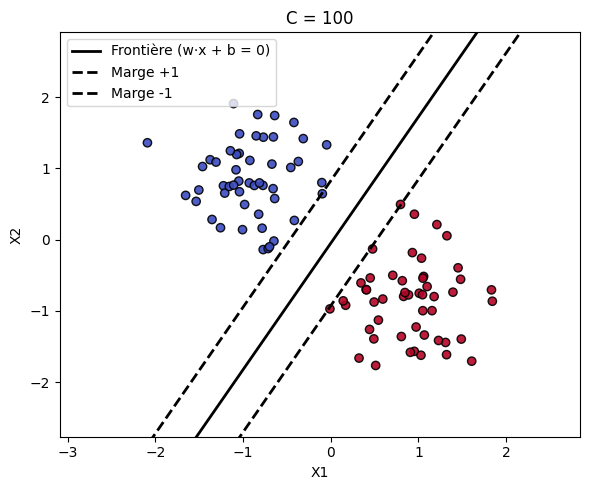

In [4]:
C = 100
model = LinearSVC(penalty='l2', loss='squared_hinge', C=C, random_state=42)
model.fit(X, y)
plot_linear_svc_with_margins(model, X, y, title=f"C = {C}")

* SVC kernel

In [5]:
import matplotlib as mpl
from sklearn.datasets import make_moons
from sklearn.svm import SVC

orange="#eb680e"
violet="#5a45a7"
dark_blue="#2a354a"

cmap = mpl.colors.ListedColormap([orange, dark_blue])

Text(0.5, 1.0, 'Données non linéaires (make_moons)')

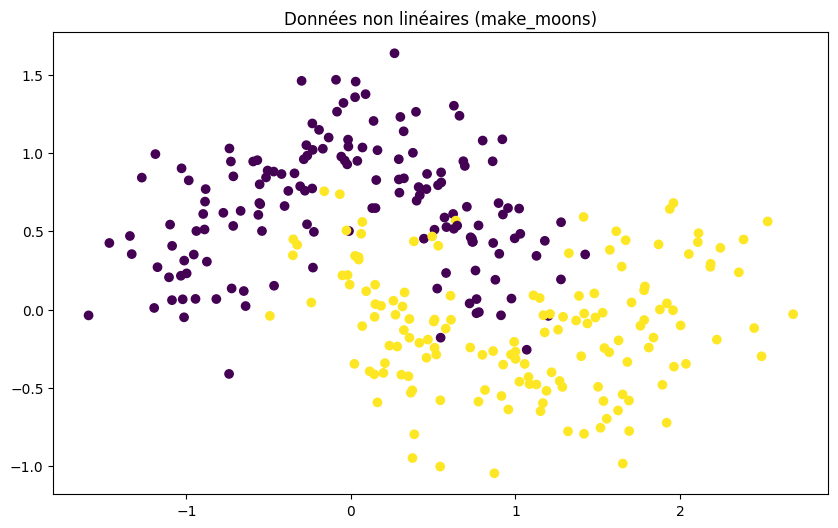

In [6]:
# Dataset non linéaire (bons pour illustrer les noyaux)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.scatter(X[:, 0], X[:, 1], c=y)
ax.set_title("Données non linéaires (make_moons)")


In [7]:
def plot_svc_kernel(model, X, y, ax=None, title=""):
    """
    Affiche la frontière de décision d'un SVC (kernel quelconque) + vecteurs de support.
    Trace aussi les niveaux de la fonction de décision (0, ±1) pour visualiser les marges.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))

    model.fit(X, y)

    # Grille
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Régions + frontière + marges
    ax.contourf(xx, yy, Z > 0, alpha=0.25, cmap=cmap)
    cs0 = ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    cs1 = ax.contour(xx, yy, Z, levels=[-1, 1], colors='k', linestyles='--', linewidths=1.5)

    # Nuage et vecteurs de support
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='k', s=35)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='k', linewidths=1.5, label='support vectors')

    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='best')
    return ax

<Axes: title={'center': 'RBF — C=100'}>

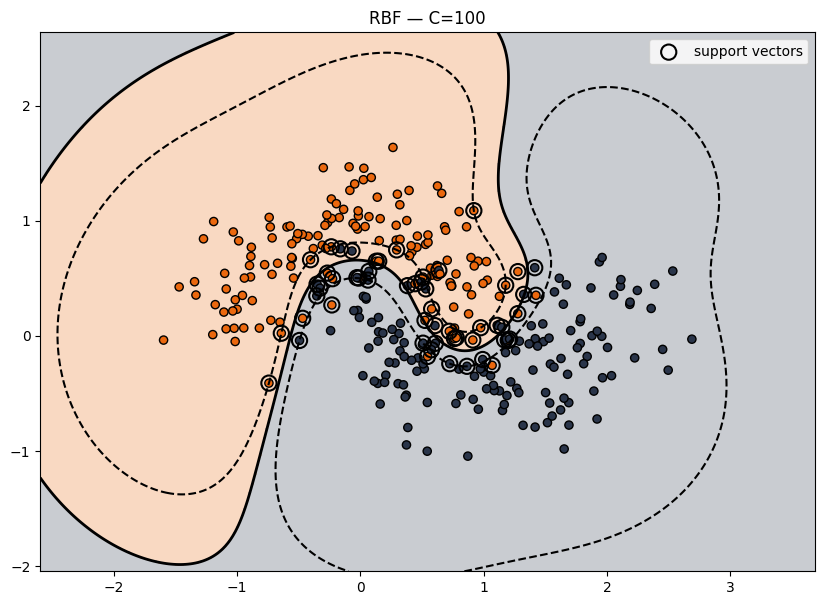

In [8]:
C = 100
clf = SVC(C=C, kernel='rbf', degree=3, gamma='scale')
plot_svc_kernel(clf, X, y, title=f"RBF — C={C}")

# regressor

In [9]:
from sklearn.svm import LinearSVR, SVR

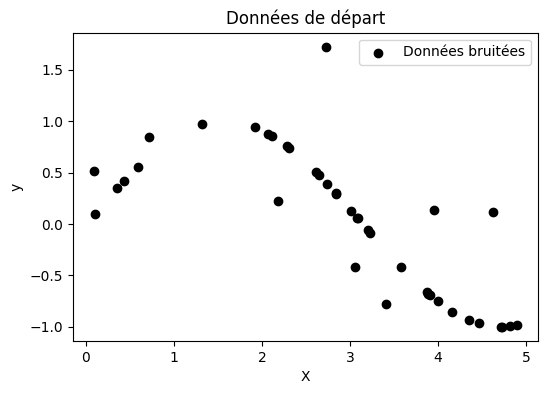

In [10]:
# On génère 40 points X entre 0 et 5 (tirés aléatoirement)
np.random.seed(0)  # pour reproductibilité
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# On ajoute du bruit tous les 5 points, de manière arbitraire
y[::5] += 3 * (0.5 - np.random.rand(8))

# Affichage rapide
plt.figure(figsize=(6,4))
plt.scatter(X, y, color="black", label="Données bruitées")
plt.title("Données de départ")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

* LinearSVR

/home/fallou/mlpro/module_3/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Text(0, 0.5, 'y')

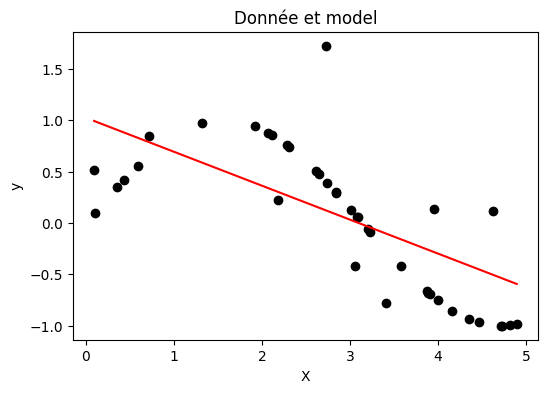

In [11]:
model = LinearSVR(epsilon=0.1, tol=0.0001, C=100, loss='epsilon_insensitive')
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color="black", label="Données bruitées")
plt.plot(X, y_pred, c="r")
plt.title("Donnée et model")
plt.xlabel("X")
plt.ylabel("y")

* SVR

Text(0, 0.5, 'y')

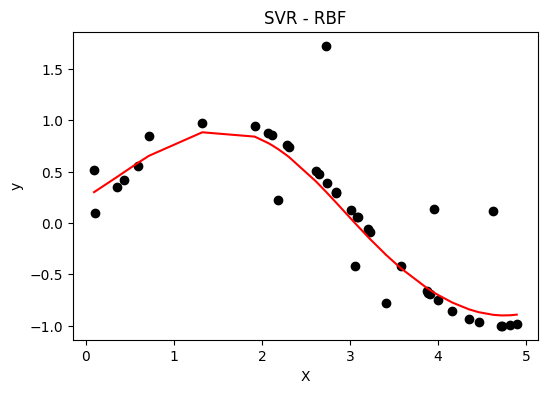

In [26]:
model = SVR(kernel='rbf', degree=3)

model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color="black", label="Données bruitées")
plt.plot(X, y_pred, c="r")
plt.title("SVR - RBF")
plt.xlabel("X")
plt.ylabel("y")

# NuSVM

In [13]:
from sklearn.svm import NuSVC, NuSVR

In [ ]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)


(300,)

<Axes: title={'center': 'NuSVC - RBF '}>

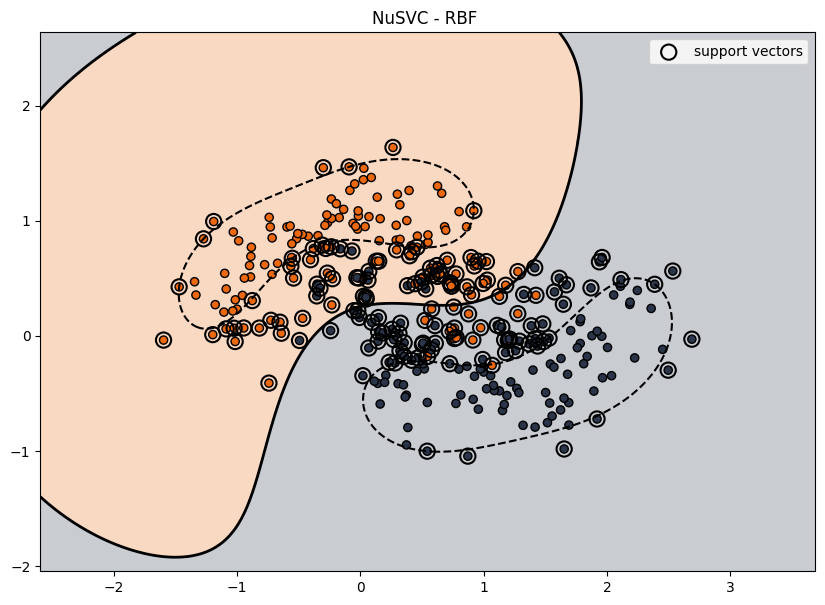

In [21]:
nusvc = NuSVC(nu=0.5, kernel='rbf', degree=3, gamma='scale')
#nusvc.fit(X, y)
plot_svc_kernel(nusvc, X, y, title=f"NuSVC - RBF ")


In [ ]:
C = 100
clf = SVC(C=C, kernel='rbf', degree=3, gamma='scale')
plot_svc_kernel(clf, X, y, title=f"RBF — C={C}")

In [22]:
# On génère 40 points X entre 0 et 5 (tirés aléatoirement)
np.random.seed(0)  # pour reproductibilité
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# On ajoute du bruit tous les 5 points, de manière arbitraire
y[::5] += 3 * (0.5 - np.random.rand(8))

Text(0, 0.5, 'y')

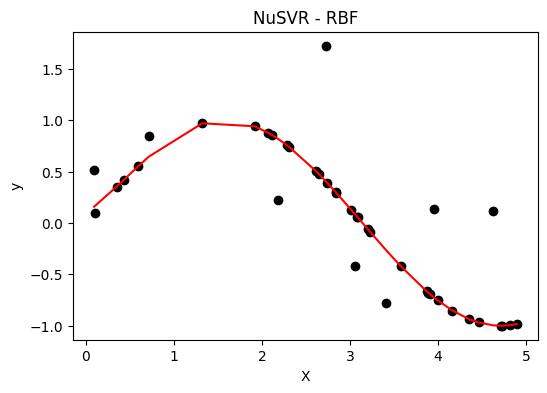

In [25]:
nusvr = NuSVR(nu=0.5, kernel='rbf', degree=3, gamma='scale')
nusvr.fit(X, y)

y_pred = nusvr.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color="black", label="Données bruitées")
plt.plot(X, y_pred, c="r")
plt.title("NuSVR - RBF")
plt.xlabel("X")
plt.ylabel("y")